# LSTM Model -- Walk-Forward Evaluation

This notebook builds and evaluates the LSTM secondary model as a standalone predictor:

1. **Data preparation** -- merge price + NLP features, create sequences with 15-day lookback
2. **Dual MinMaxScalers** -- separate scalers for features and target (from SOTA)
3. **LSTM model** -- 2-layer, 64 units, orthogonal init, dropout, early stopping, jitter augmentation
4. **Walk-forward validation** -- expanding window, per-ticker batching, verbose progress
5. **Results** -- standalone LSTM vs naive baseline, per-ticker breakdown
6. **Save predictions** -- export to disk for the ensemble notebook

**Input:** `features_price.csv`, `features_nlp.csv`  
**Output:** `lstm_predictions.pkl`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

DATA_DIR = '.'
RANDOM_STATE = 42
DEVICE = 'mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu')

np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

print(f'Device: {DEVICE}')

Device: cpu (forced CPU -- dataset is small enough, avoids MPS memory issues)


## 1. Load and Merge Features

In [2]:
price_features = pd.read_csv(f'{DATA_DIR}/features_price.csv', parse_dates=['date'])
nlp_features = pd.read_csv(f'{DATA_DIR}/features_nlp.csv', parse_dates=['date'])

df = price_features.merge(nlp_features, on=['date', 'ticker'], how='left')
df = df.sort_values(['ticker', 'date']).reset_index(drop=True)

nlp_cols = [c for c in nlp_features.columns if c not in ['date', 'ticker']]
for col in nlp_cols:
    if col == 'has_news':
        df[col] = df[col].fillna(0).astype(int)
    else:
        df[col] = df[col].fillna(0.0)

df = df.dropna(subset=['target_next_close']).reset_index(drop=True)

tickers = sorted(df['ticker'].unique())

META_COLS = ['date', 'ticker']
TARGET_COLS = ['target_next_close', 'target_next_return', 'target_direction']
OHLCV_COLS = ['open', 'high', 'low', 'close', 'volume']
EXCLUDE_COLS = META_COLS + TARGET_COLS + ['is_outlier']

price_feature_cols = [c for c in price_features.columns if c not in EXCLUDE_COLS + OHLCV_COLS]
nlp_feature_cols = list(nlp_cols)
all_feature_cols = price_feature_cols + nlp_feature_cols

print(f'Merged shape: {df.shape}')
print(f'Total features: {len(all_feature_cols)}')
print(f'Tickers: {tickers}')

Merged shape: (1449, 82)
Total features: 71
Tickers: ['AAPL', 'AMZN', 'GOOGL', 'META', 'MSFT', 'NVDA', 'TSLA']


## 2. Sequence Creation and Dataset

In [3]:
LOOKBACK = 15
JITTER_STD = 0.01


class StockSequenceDataset(Dataset):
    def __init__(self, X_seq, y_seq, jitter=False, jitter_std=0.01):
        self.X = torch.FloatTensor(X_seq)
        self.y = torch.FloatTensor(y_seq)
        self.jitter = jitter
        self.jitter_std = jitter_std

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx]
        if self.jitter:
            x = x + torch.randn_like(x) * self.jitter_std
        return x, self.y[idx]


def create_sequences(features, targets, lookback):
    """Create overlapping sequences of length `lookback` from scaled feature/target arrays."""
    X_seq, y_seq = [], []
    for i in range(lookback, len(features)):
        X_seq.append(features[i - lookback:i])
        y_seq.append(targets[i])
    return np.array(X_seq), np.array(y_seq)


print(f'Lookback window: {LOOKBACK} days')
print(f'Jitter augmentation std: {JITTER_STD}')

Lookback window: 15 days
Jitter augmentation std: 0.01


## 3. LSTM Model Definition

In [4]:
class StockLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )
        self._init_weights()

    def _init_weights(self):
        for name, param in self.lstm.named_parameters():
            if 'weight_ih_l0' in name:
                nn.init.orthogonal_(param)
            elif 'weight_hh' in name:
                nn.init.orthogonal_(param)
            elif 'bias' in name:
                nn.init.zeros_(param)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_hidden = lstm_out[:, -1, :]
        return self.fc(last_hidden).squeeze(-1)


print(f'Model architecture: LSTM(2 layers, 64 units) -> Dense(32) -> Dense(1)')
print(f'Initialization: orthogonal (first layer weights, from SOTA Notebook 5)')

Model architecture: LSTM(2 layers, 64 units) -> Dense(32) -> Dense(1)
Initialization: orthogonal (first layer weights, from SOTA Notebook 5)


## 4. Training Function with Early Stopping

In [5]:
def train_lstm(model, train_loader, val_X, val_y, device,
               epochs=150, lr=5e-4, patience=15, verbose=True):
    """Train LSTM with early stopping on validation loss."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5
    )

    model.to(device)
    val_X_tensor = torch.FloatTensor(val_X).to(device)
    val_y_tensor = torch.FloatTensor(val_y).to(device)

    best_val_loss = float('inf')
    best_state = None
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        train_losses = []
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            optimizer.zero_grad()
            preds = model(batch_X)
            loss = criterion(preds, batch_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            val_preds = model(val_X_tensor)
            val_loss = criterion(val_preds, val_y_tensor).item()

        scheduler.step(val_loss)

        improved = ''
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
            improved = ' *'
        else:
            patience_counter += 1

        if verbose and (epoch % 10 == 0 or patience_counter >= patience or epoch == epochs - 1):
            avg_train = np.mean(train_losses)
            print(f'    Epoch {epoch+1:>3}/{epochs}  train_loss={avg_train:.6f}  '
                  f'val_loss={val_loss:.6f}  patience={patience_counter}/{patience}{improved}')

        if patience_counter >= patience:
            if verbose:
                print(f'    Early stopping at epoch {epoch+1}')
            break

    model.load_state_dict(best_state)
    return model, epoch + 1, best_val_loss


print('Training function ready (Adam, lr=5e-4, patience=15, grad clipping=1.0)')

Training function ready (Adam, lr=5e-4, patience=15, grad clipping=1.0)


## 5. Walk-Forward LSTM Evaluation (Standalone)

Same expanding window as the XGBoost notebook:
- Initial training: 60% of data
- Step forward 5 days at a time
- At each step: scale data with dual scalers, create sequences, train LSTM, predict
- Progress printed every 10 epochs per step

In [6]:
def compute_metrics(actual, predicted):
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae = mean_absolute_error(actual, predicted)
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    actual_dir = np.diff(actual) > 0
    pred_dir = np.diff(predicted) > 0
    dir_acc = np.mean(actual_dir == pred_dir) * 100 if len(actual_dir) > 0 else 0.0
    return {'RMSE': rmse, 'MAE': mae, 'MAPE': mape, 'Dir_Acc': dir_acc}

In [7]:
INITIAL_TRAIN_PCT = 0.6
STEP_SIZE = 5
HIDDEN_SIZE = 64
NUM_LAYERS = 2
DROPOUT = 0.2
BATCH_SIZE = 16
EPOCHS = 150
PATIENCE = 15

lstm_results = {}

for ticker in tickers:
    print(f'\n{"=" * 60}')
    print(f'  LSTM Walk-Forward: {ticker}')
    print(f'{"=" * 60}')

    sub = df[df['ticker'] == ticker].copy().reset_index(drop=True)
    n = len(sub)
    initial_train_size = int(n * INITIAL_TRAIN_PCT)

    dates_all = sub['date'].values
    features_raw = sub[all_feature_cols].values
    target_raw = sub['target_next_close'].values
    close_raw = sub['close'].values

    lstm_predictions = []
    naive_predictions = []
    actuals = []
    pred_dates = []

    train_end = initial_train_size
    step_num = 0

    while train_end < n:
        predict_end = min(train_end + STEP_SIZE, n)
        step_num += 1

        # --- Dual scalers (fit on training data only) ---
        feature_scaler = MinMaxScaler(feature_range=(-1, 1))
        target_scaler = MinMaxScaler(feature_range=(-1, 1))

        feature_scaler.fit(features_raw[:train_end])
        target_scaler.fit(target_raw[:train_end].reshape(-1, 1))

        features_all_scaled = feature_scaler.transform(features_raw[:predict_end])
        target_all_scaled = target_scaler.transform(target_raw[:predict_end].reshape(-1, 1)).flatten()

        # --- Create sequences ---
        X_seq_all, y_seq_all = create_sequences(features_all_scaled, target_all_scaled, LOOKBACK)

        seq_train_end = train_end - LOOKBACK
        if seq_train_end < 20:
            train_end = predict_end
            continue

        val_size = max(int(seq_train_end * 0.2), 5)
        lstm_train_end = seq_train_end - val_size

        X_train_seq = X_seq_all[:lstm_train_end]
        y_train_seq = y_seq_all[:lstm_train_end]
        X_val_seq = X_seq_all[lstm_train_end:seq_train_end]
        y_val_seq = y_seq_all[lstm_train_end:seq_train_end]
        X_test_seq = X_seq_all[seq_train_end:predict_end - LOOKBACK]

        if len(X_test_seq) == 0 or len(X_train_seq) < 20:
            train_end = predict_end
            continue

        print(f'\n  Step {step_num} (train_end={train_end}, train_seqs={len(X_train_seq)}, '
              f'val_seqs={len(X_val_seq)}, test_seqs={len(X_test_seq)})')

        # --- Train LSTM ---
        train_dataset = StockSequenceDataset(X_train_seq, y_train_seq, jitter=True, jitter_std=JITTER_STD)
        train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

        model = StockLSTM(
            input_size=len(all_feature_cols),
            hidden_size=HIDDEN_SIZE,
            num_layers=NUM_LAYERS,
            dropout=DROPOUT
        )

        model, stopped_epoch, best_val = train_lstm(
            model, train_loader, X_val_seq, y_val_seq, DEVICE,
            epochs=EPOCHS, patience=PATIENCE, verbose=True
        )

        # --- LSTM predictions ---
        model.eval()
        model.to(DEVICE)
        with torch.no_grad():
            X_test_tensor = torch.FloatTensor(X_test_seq).to(DEVICE)
            lstm_preds_scaled = model(X_test_tensor).cpu().numpy()

        lstm_preds = target_scaler.inverse_transform(lstm_preds_scaled.reshape(-1, 1)).flatten()

        # --- Align with original data ---
        test_start_orig = train_end
        num_preds = min(len(lstm_preds), n - test_start_orig)
        lstm_preds = lstm_preds[:num_preds]

        test_actuals = target_raw[test_start_orig:test_start_orig + num_preds]
        test_naive = close_raw[test_start_orig:test_start_orig + num_preds]
        test_dates_slice = dates_all[test_start_orig:test_start_orig + num_preds]

        lstm_predictions.extend(lstm_preds.tolist())
        naive_predictions.extend(test_naive.tolist())
        actuals.extend(test_actuals.tolist())
        pred_dates.extend(test_dates_slice.tolist())

        print(f'  -> Predicted {num_preds} days (stopped epoch {stopped_epoch}, best_val={best_val:.6f})')

        del model, train_dataset, train_loader, X_test_tensor, lstm_preds_scaled
        if DEVICE == 'mps':
            torch.mps.empty_cache()

        train_end = predict_end

    # --- Store LSTM-only results ---
    actuals_arr = np.array(actuals)
    lstm_arr = np.array(lstm_predictions)
    naive_arr = np.array(naive_predictions)

    lstm_results[ticker] = {
        'dates': pred_dates,
        'actuals': actuals_arr,
        'naive': naive_arr,
        'lstm': lstm_arr,
        'metrics_naive': compute_metrics(actuals_arr, naive_arr),
        'metrics_lstm': compute_metrics(actuals_arr, lstm_arr),
    }

    print(f'\n  {ticker} LSTM Results:')
    for name in ['metrics_naive', 'metrics_lstm']:
        m = lstm_results[ticker][name]
        label = name.replace('metrics_', '').upper()
        print(f'    {label:<10} RMSE={m["RMSE"]:.2f}  MAE={m["MAE"]:.2f}  '
              f'MAPE={m["MAPE"]:.2f}%  Dir_Acc={m["Dir_Acc"]:.1f}%')

import gc
if DEVICE == 'mps':
    torch.mps.empty_cache()
elif DEVICE == 'cuda':
    torch.cuda.empty_cache()
gc.collect()

print('\n' + '=' * 60)
print('LSTM walk-forward completed for all tickers.')
print('GPU/MPS memory cleared.')


  LSTM Walk-Forward: AAPL

  Step 1 (train_end=124, train_seqs=88, val_seqs=21, test_seqs=5)
    Epoch   1/150  train_loss=0.406946  val_loss=0.382786  patience=0/15 *
    Epoch  11/150  train_loss=0.057312  val_loss=0.454475  patience=10/15
    Epoch  16/150  train_loss=0.030212  val_loss=0.401045  patience=15/15
    Early stopping at epoch 16
  -> Predicted 5 days (stopped epoch 16, best_val=0.382786)

  Step 2 (train_end=129, train_seqs=92, val_seqs=22, test_seqs=5)
    Epoch   1/150  train_loss=0.185187  val_loss=0.590561  patience=0/15 *
    Epoch  11/150  train_loss=0.020416  val_loss=0.531023  patience=0/15 *
    Epoch  21/150  train_loss=0.011859  val_loss=0.530864  patience=0/15 *
    Epoch  31/150  train_loss=0.010237  val_loss=0.531030  patience=3/15
    Epoch  41/150  train_loss=0.011105  val_loss=0.529270  patience=0/15 *
    Epoch  51/150  train_loss=0.011154  val_loss=0.530769  patience=10/15
    Epoch  56/150  train_loss=0.012667  val_loss=0.530940  patience=15/15
    

## 6. LSTM Standalone Results

In [8]:
lstm_rows = []

for ticker in tickers:
    r = lstm_results[ticker]
    for model_name, key in [('Naive', 'metrics_naive'), ('LSTM', 'metrics_lstm')]:
        lstm_rows.append({'Ticker': ticker, 'Model': model_name, **r[key]})

lstm_comparison_df = pd.DataFrame(lstm_rows)

print('=== LSTM Standalone vs Naive ===')
summary = lstm_comparison_df.groupby('Model')[['RMSE', 'MAE', 'MAPE', 'Dir_Acc']].mean().round(2)
summary = summary.reindex(['Naive', 'LSTM'])
display(summary)

print('\n=== Per-Ticker Breakdown ===')
print(f'{"Ticker":<8} {"Model":<12} {"RMSE":>8} {"MAE":>8} {"MAPE%":>8} {"Dir%":>8}')
print('-' * 54)
for ticker in tickers:
    for model_name, key in [('Naive', 'metrics_naive'), ('LSTM', 'metrics_lstm')]:
        m = lstm_results[ticker][key]
        print(f'{ticker:<8} {model_name:<12} {m["RMSE"]:>8.2f} {m["MAE"]:>8.2f} '
              f'{m["MAPE"]:>8.2f} {m["Dir_Acc"]:>8.1f}')

=== LSTM Standalone vs Naive ===


,RMSE,MAE,MAPE,Dir_Acc
Model,,,,
Naive,5.56,4.09,1.70,48.08
LSTM,19.58,15.78,6.25,49.48



=== Per-Ticker Breakdown ===
Ticker   Model            RMSE      MAE    MAPE%     Dir%
------------------------------------------------------
AAPL     Naive            3.14     2.32     1.04     48.8
AAPL     LSTM            18.74    15.81     7.00     45.1
AMZN     Naive            3.38     2.42     1.34     48.8
AMZN     LSTM             8.11     5.86     3.22     59.8
GOOGL    Naive            2.59     1.93     1.16     56.1
GOOGL    LSTM            10.79     8.42     5.01     46.3
META     Naive           10.14     7.38     1.42     43.9
META     LSTM            37.59    32.14     5.90     50.0
MSFT     Naive            5.07     3.94     0.93     54.9
MSFT     LSTM            16.98    12.77     2.94     42.7
NVDA     Naive            4.35     3.42     2.88     41.5
NVDA     LSTM            14.53    12.48    10.02     51.2
TSLA     Naive           10.24     7.20     3.13     42.7
TSLA     LSTM            30.32    22.96     9.62     51.2


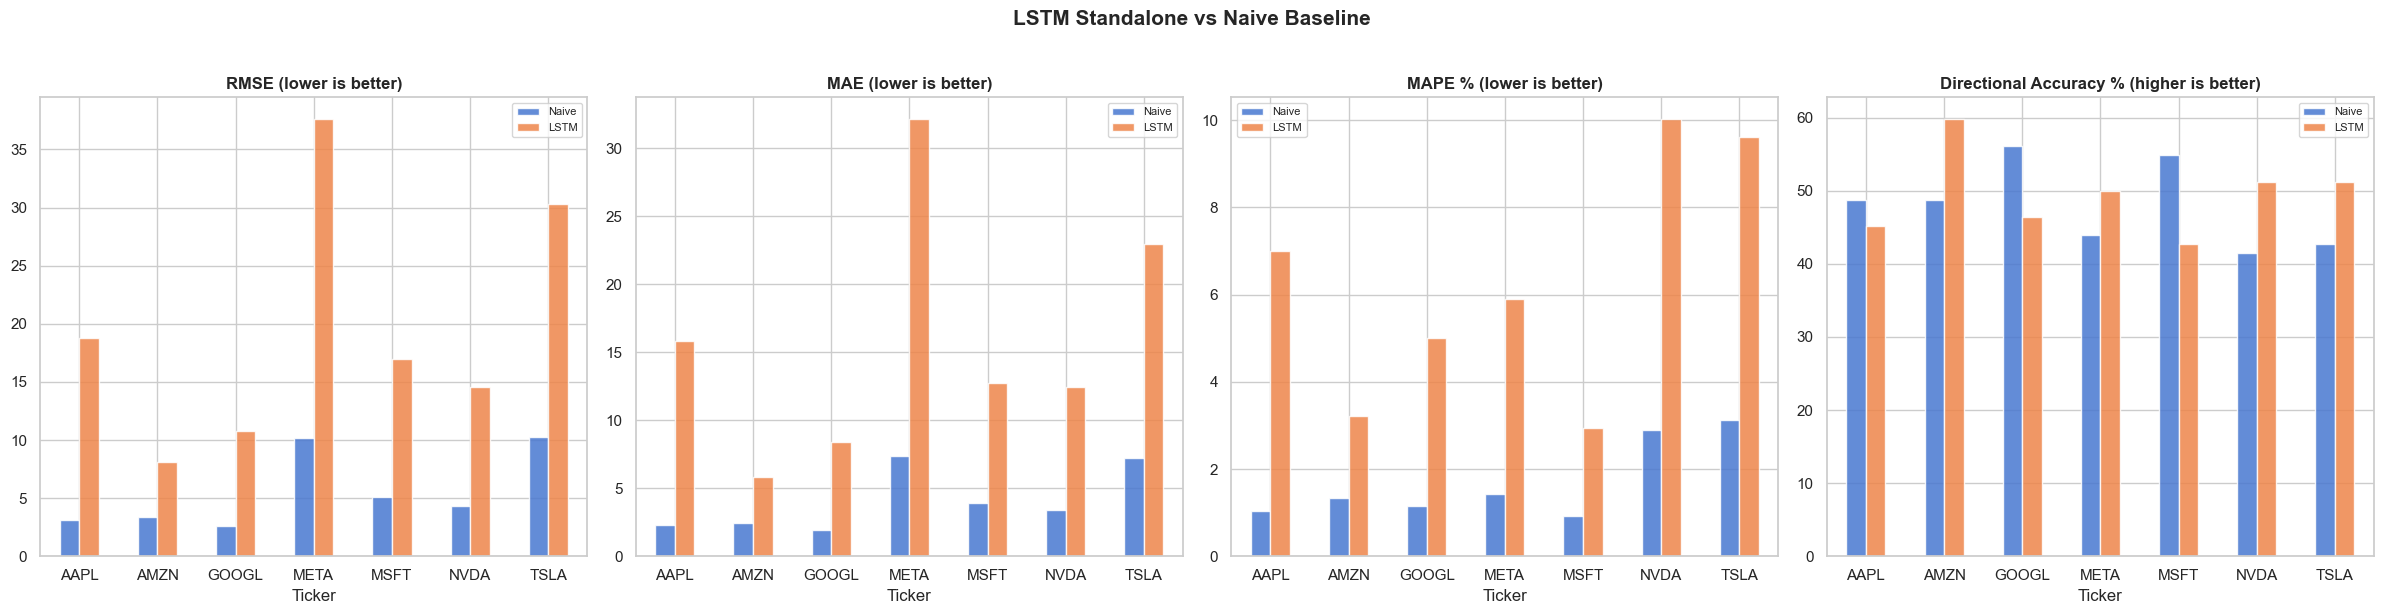

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(24, 6))
metrics = ['RMSE', 'MAE', 'MAPE', 'Dir_Acc']
titles = ['RMSE (lower is better)', 'MAE (lower is better)',
          'MAPE % (lower is better)', 'Directional Accuracy % (higher is better)']

for ax, metric, title in zip(axes, metrics, titles):
    pivot = lstm_comparison_df.pivot(index='Ticker', columns='Model', values=metric)
    pivot = pivot[['Naive', 'LSTM']]
    pivot.plot(kind='bar', ax=ax, edgecolor='white', alpha=0.85)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=0)
    ax.legend(fontsize=8)

plt.suptitle('LSTM Standalone vs Naive Baseline', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 7. Predicted vs Actual -- LSTM Standalone

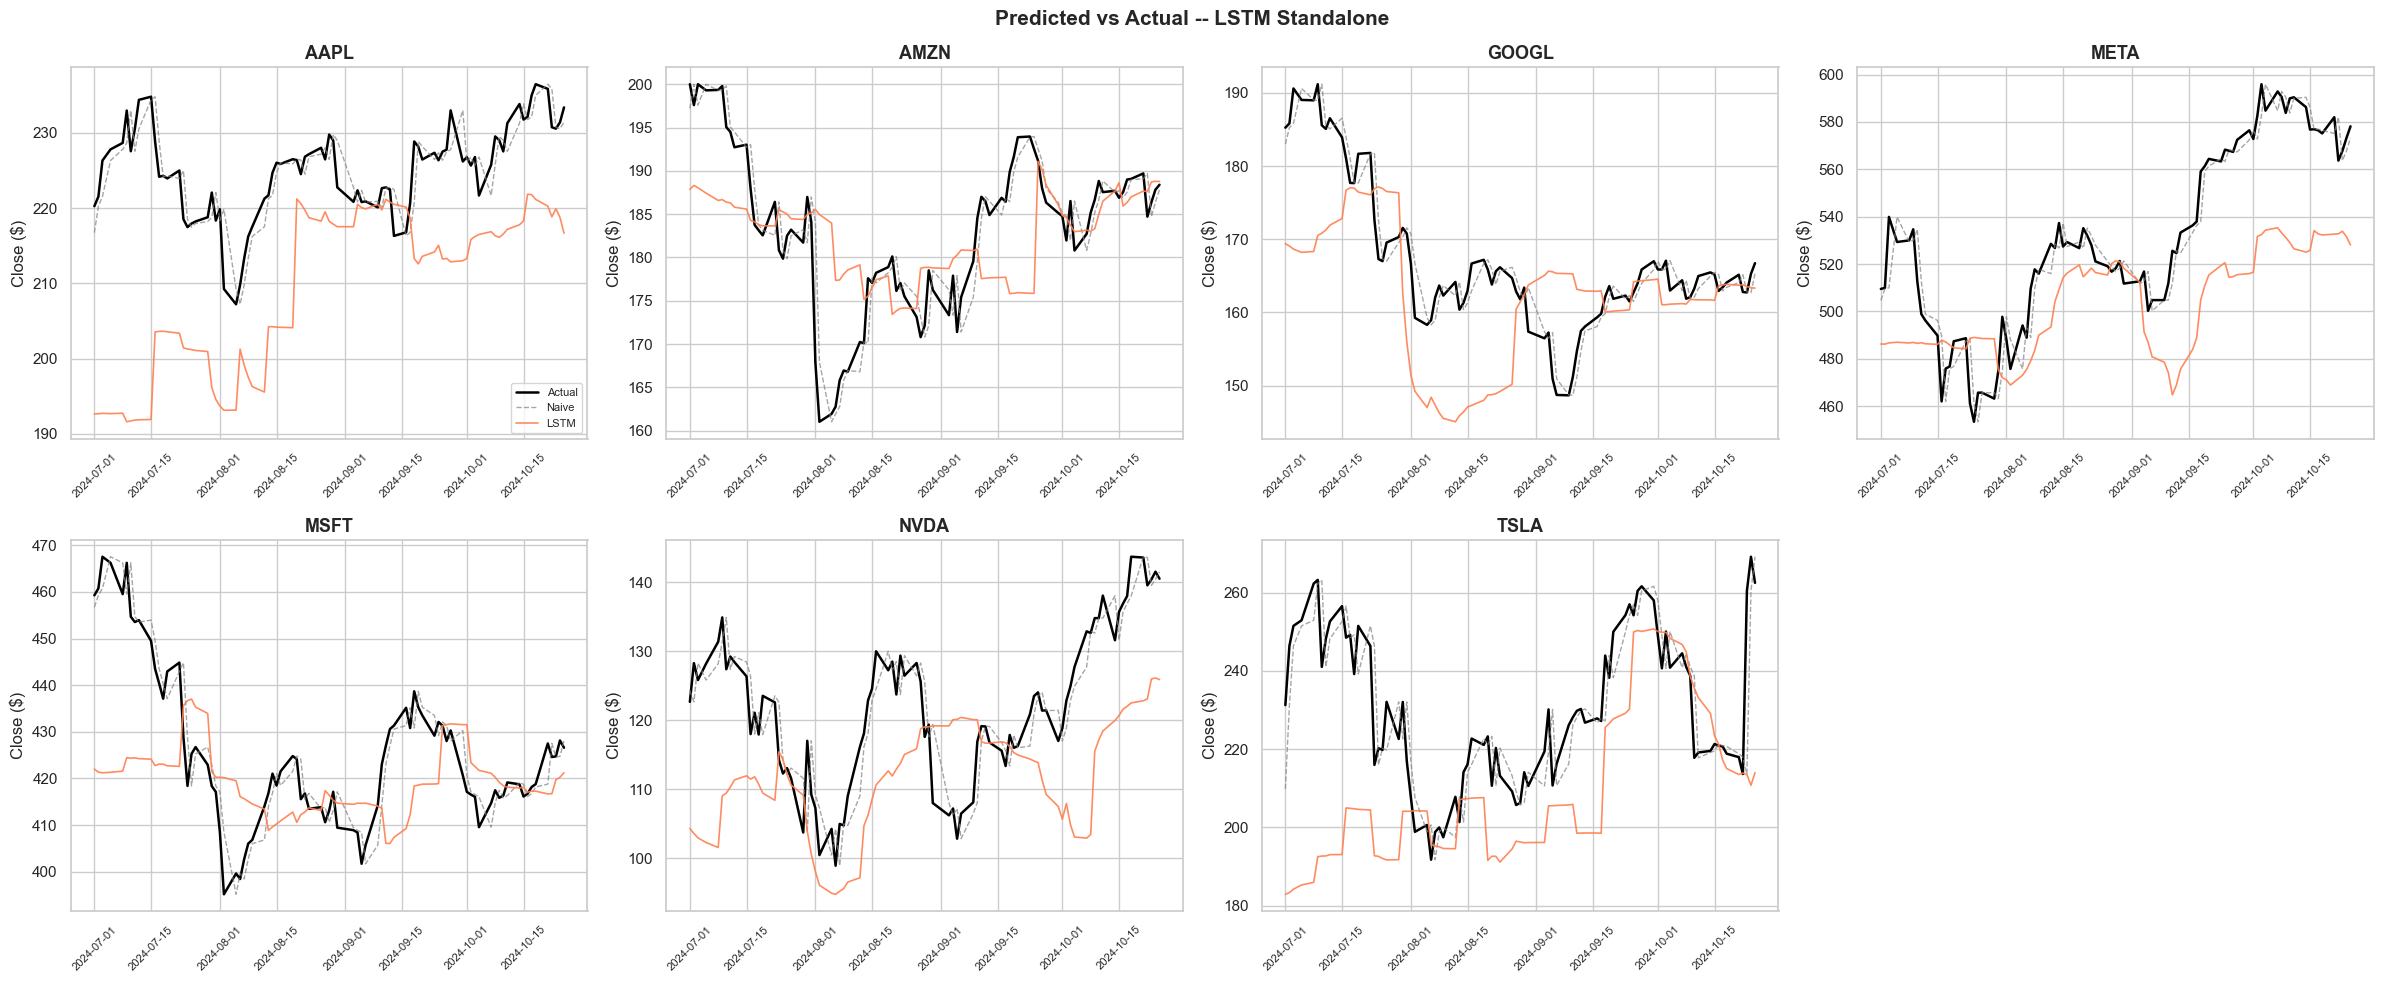

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(24, 10))
axes = axes.flatten()

for i, ticker in enumerate(tickers):
    r = lstm_results[ticker]
    dates = r['dates']

    axes[i].plot(dates, r['actuals'], label='Actual', linewidth=1.8, color='black')
    axes[i].plot(dates, r['naive'], label='Naive', linewidth=1.0, color='gray', alpha=0.7, linestyle='--')
    axes[i].plot(dates, r['lstm'], label='LSTM', linewidth=1.2, color='coral', alpha=0.9)

    axes[i].set_title(ticker, fontsize=13, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=45, labelsize=8)
    axes[i].set_ylabel('Close ($)')
    if i == 0:
        axes[i].legend(fontsize=8)

axes[-1].set_visible(False)
fig.suptitle('Predicted vs Actual -- LSTM Standalone', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Save LSTM Predictions for Ensemble Notebook

Export the walk-forward LSTM predictions so the ensemble notebook can load them without re-training.

In [ ]:
import pickle

save_data = {
    'lstm_results': lstm_results,
    'tickers': tickers,
    'all_feature_cols': all_feature_cols,
    'price_feature_cols': price_feature_cols,
    'nlp_feature_cols': nlp_feature_cols,
    'config': {
        'INITIAL_TRAIN_PCT': INITIAL_TRAIN_PCT,
        'STEP_SIZE': STEP_SIZE,
        'LOOKBACK': LOOKBACK,
    }
}

with open('lstm_predictions.pkl', 'wb') as f:
    pickle.dump(save_data, f)

print(f'Saved lstm_predictions.pkl')
print(f'  Tickers: {tickers}')
for ticker in tickers:
    r = lstm_results[ticker]
    print(f'  {ticker}: {len(r["lstm"])} predictions')

## Conclusions

### LSTM Standalone Performance

The LSTM model was evaluated independently against the naive baseline (previous day's close) using walk-forward validation across 7 tickers.

**Key observations to verify from the results above (Section 6):**

- LSTM RMSE and MAE compared to the naive baseline per ticker
- Whether directional accuracy improves with the sequence-based approach
- Which tickers benefit most from the LSTM's temporal pattern learning

### Architecture & Techniques

| Component | Choice | Rationale |
|-----------|--------|-----------|
| Layers | 2-layer LSTM, 64 hidden units | Small to avoid overfitting on ~200 samples/ticker |
| Initialization | Orthogonal (first layer) | From SOTA Notebook 5, helps gradient flow |
| Regularization | Dropout 0.2 + early stopping (patience=15) | Prevents overfitting on small data |
| Augmentation | Jitter (std=0.01) | From SOTA Notebook 4, synthetic training diversity |
| Scaling | Dual MinMaxScalers (-1, 1) | Separate scalers for features and target |
| Lookback | 15 days | Balance between context and sample count |
| Validation | Walk-forward, expanding window, 5-day step | Time-series aware, no look-ahead bias |

### Next Steps

LSTM predictions have been saved to `lstm_predictions.pkl`. The **ensemble notebook** will:
1. Load these LSTM predictions
2. Run XGBoost walk-forward on the same splits
3. Build a weighted ensemble (LSTM + XGBoost)
4. Compare all models and optimize ensemble weights